In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.impute import SimpleImputer
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [2]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("insurance_claims.csv")

print("Shape:", df.shape)

Shape: (8000, 10)


In [3]:
print("Columns:")
print(df.columns.to_list())

Columns:
['claim_id', 'claim_amount', 'customer_tenure_months', 'age', 'prior_claims', 'days_to_report', 'policy_type', 'region', 'channel', 'is_fraud']


In [4]:
print("Missing Values:")
print(df.isna().sum())

Missing Values:
claim_id                    0
claim_amount                0
customer_tenure_months      0
age                       120
prior_claims                0
days_to_report             90
policy_type                 0
region                      0
channel                     0
is_fraud                    0
dtype: int64


In [5]:
fraud_rate = df["is_fraud"].mean()

print(f"Fraud Rate is {fraud_rate:.4f} ({fraud_rate*100:.2f}%)")

Fraud Rate is 0.0369 (3.69%)


In [6]:
df.head(5)

,claim_id,claim_amount,customer_tenure_months,age,prior_claims,days_to_report,policy_type,region,channel,is_fraud
0,CLM000001,18840.68,31,30.0,0,0.0,Premium,South,Online,0
1,CLM000002,6425.39,19,42.0,0,NaN,Basic,East,Broker,0
2,CLM000003,26912.90,8,55.0,1,11.0,Basic,North,Broker,1
3,CLM000004,31333.77,26,57.0,0,7.0,Standard,East,Broker,0
4,CLM000005,3100.04,3,58.0,1,18.0,Standard,South,Agent,0


In [7]:
num_features = ["claim_amount", "customer_tenure_months", "age",
               "prior_claims", "days_to_report"]

cat_features = ["policy_type", "region", "channel"]

X_real = df.drop(columns=["claim_id", "is_fraud"])
y_real = df["is_fraud"].to_numpy()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("impurter", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), num_features
        ), (
            "cat", 
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ("sclaer", StandardScaler())
            ]), cat_features
        )
    ]
)

X_scaled = preprocessor.fit_transform(X_real)

print("Processed feature shape:", X_scaled.shape)

Processed feature shape: (8000, 15)


# **Part A — Why simple methods are not enough**
## **TASK 01 — Build an anomaly that per-feature methods cannot see**

In [8]:
rng = np.random.default_rng(42)
X_normal = rng.multivariate_normal(
    mean = [0, 0],
    cov = [[1, 0.9], [0.9, 1]],
    size = 1000
)

normal_std = X_normal.std(axis=0)

anomalies = np.array([
    [2 * normal_std[0], -2 * normal_std[1]]
] * 5)

X_01 = np.vstack([X_normal, anomalies])
y_01 = np.r_[np.zeros(1000), np.ones(5)]

mean = X_01.mean(axis=0)
std = X_01.std(axis=0)

z_scores = np.abs((X_01 - mean) / std).max(axis=1)

inject_max_z = z_scores[-5:]

top5_z = np.argsort(z_scores)[-5:]

caught_z = sum(index in top5_z
              for index in range(1000, 1005))

print("Maximum absolute z-score for each injected anomaly:")
print(np.round(inject_max_z, 2))
print(f"\nInjected anomalies appearing in z-score top 5: {caught_z} out of 5")

Maximum absolute z-score for each injected anomaly:
[2.04 2.04 2.04 2.04 2.04]

Injected anomalies appearing in z-score top 5: 0 out of 5


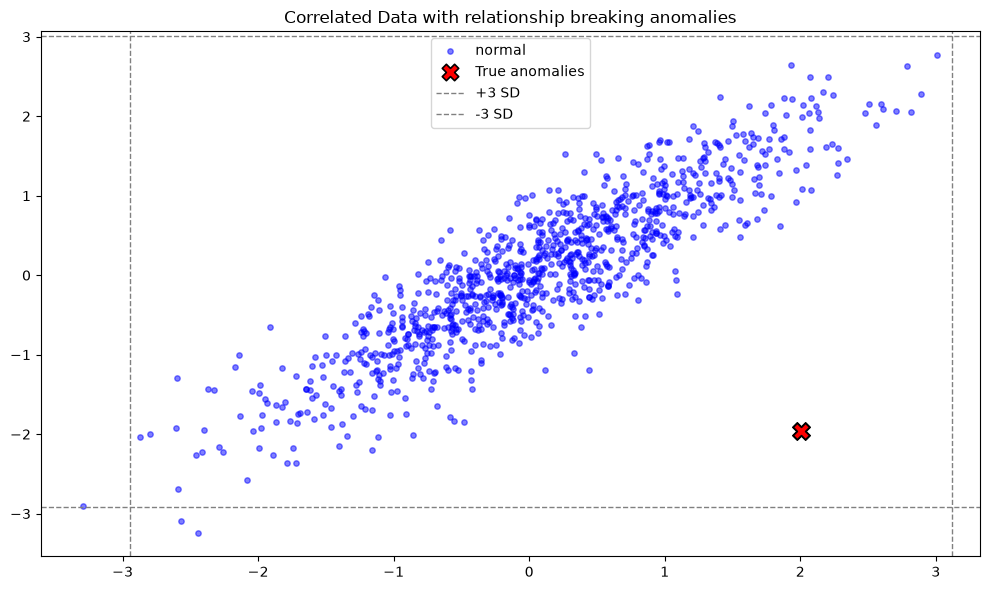

In [9]:
# Plot the data
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_normal[:, 0], X_normal[:, 1], s=15, label="normal", alpha=0.5, color="blue")
ax.scatter(anomalies[:, 0], anomalies[:, 1], s=140, color="red", marker="X", label="True anomalies",
          edgecolors="black", lw=1.2)

x_limits = ax.get_xlim()
y_limits = ax.get_ylim()

ax.axvline(mean[0] + 3 * std[0], ls="--", lw=1, color="gray", label="+3 SD")
ax.axvline(mean[0] - 3 * std[0], ls="--", lw=1, color="gray", label="-3 SD")
ax.axhline(mean[1] + 3 * std[1], ls="--", lw=1, color="gray")
ax.axhline(mean[1] - 3 * std[1], ls="--", lw=1, color="gray")

ax.set_xlim(x_limits)
ax.set_ylim(y_limits)

ax.set_title("Correlated Data with relationship breaking anomalies")
ax.legend()

plt.tight_layout()
plt.show()

* A point can be ordinary in every individual column but still be impossible because the combination of its feature values breaks the relationship learned from normal data.
* A real-world example is a claim whose amount and reporting delay are individually normal, but their combination is highly unusual for the normal pattern.

## **TASK 02 — Apply IQR and compare**

In [10]:
def iqr_anomaly_score(X):
    q1 = np.quantile(X, 0.25, axis=0)
    q3 = np.quantile(X, 0.75, axis=0)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    flags = (X < lower) | (X > upper)

    return flags.sum(axis=1), flags, q1, q3, iqr

iqr_score_01, _, _, _, _ = iqr_anomaly_score(X_01)

top5_iqr = np.argsort(iqr_score_01)[-5:]

caught_iqr = sum(
    index in top5_iqr
    for index in range(1000, 1005)
)

print(f"IQR anomalies appearing in its top 5: {caught_iqr} out of 5")

IQR anomalies appearing in its top 5: 0 out of 5


In [11]:
extreme_values = rng.normal(0, 20, 50)

extra_outliers = np.column_stack([
    extreme_values, rng.normal(0, 1, 50)
])

X_02 = np.vstack([
    X_01, extra_outliers
])

std_before = X_01[:, 0].std()
std_after = X_02[:, 0].std()

z_02 = np.abs(
    (X_02 - X_02.mean(axis=0)) / X_02.std(axis=0)
)

iqr_score_02, _, q1_before, q3_before, iqr_before = iqr_anomaly_score(X_01)
_, _, q1_after, q3_after, iqr_after = iqr_anomaly_score(X_02)

lower_before = q1_before[0] - 1.5 * iqr_before[0]
upper_before = q3_before[0] + 1.5 * iqr_before[0]

lower_after = q1_after[0] - 1.5 * iqr_after[0]
upper_after = q3_after[0] + 1.5 * iqr_after[0]


print(f"Feature 1 standard deviation before adding outliers: {std_before:.3f}")
print(f"Feature 1 standard deviation after adding outliers: {std_after:.3f}")
print()
print(f"Injected anomaly z-scores on Feature 1 before:")
print(np.round(z_scores[-5:], 3))
print()
print(f"Injected anomaly z-scores on Feature 1 after:")
print(np.round(z_02[1000:1005, 0], 3))
print()
print("IQR fences before:")
print(f"Lower = {lower_before:.3f}, Upper = {upper_before:.3f}")
print()
print("IQR fences after:")
print(f"Lower = {lower_after:.3f}, Upper = {upper_after:.3f}")

Feature 1 standard deviation before adding outliers: 1.011
Feature 1 standard deviation after adding outliers: 4.186

Injected anomaly z-scores on Feature 1 before:
[2.036 2.036 2.036 2.036 2.036]

Injected anomaly z-scores on Feature 1 after:
[0.462 0.462 0.462 0.462 0.462]

IQR fences before:
Lower = -2.591, Upper = 2.780

IQR fences after:
Lower = -2.715, Upper = 2.956


**Conclusion -->**
* The 50 extreme outliers increases the standard deviation, which makes the original anomalies' z-scores much smaller.
* The IQR fences move much less because they depend on the quartiles rather than the standard deviation.
* This show why IQR is generally preferable to z-score when the data already contains substaintial outliers.

# **Part B — Methods that look at the data jointly**
## **TASK 03 — LOF and Isolation Forest**

In [14]:
lof_01 = LocalOutlierFactor(n_neighbors=20, contamination="auto")
lof_01.fit(X_01)
lof_scores_01 = -lof_01.negative_outlier_factor_

isolation_01 = IsolationForest(n_estimators=300, contamination="auto", random_state=42)
isolation_01.fit(X_01)
isolation_scores_01 = -isolation_01.score_samples(X_01)

z_auc_01 = roc_auc_score(y_01, z_scores)
lof_auc_01 = roc_auc_score(y_01, lof_scores_01)
isolation_auc_01 = roc_auc_score(y_01, isolation_scores_01)

def top5_caught(score):
    top5 = np.argsort(score)[-5:]
    return sum(index in top5 for index in range(1000, 1005))

print(f"Z-score auc: {z_auc_01:.3f}")
print(f"LOF auc: {lof_auc_01:.3f}")
print(f"Isolation forest auc: {isolation_auc_01:.3f}")

print(f"\nInjected anomalies in top 5")
print(f"z-score: {top5_caught(z_scores)}")
print(f"LOF: {top5_caught(lof_scores_01)}")
print(f"Isolation Forest: {top5_caught(isolation_scores_01)}")

Z-score auc: 0.937
LOF auc: 1.000
Isolation forest auc: 0.993

Injected anomalies in top 5
z-score: 0
LOF: 5
Isolation Forest: 0


**Conclusion -->**
* A high AUC can coexist with a weak top-of-list because AUC measures ranking quality across the thresholds, while a review team may only inspect the first few cases.
* Therefore, anomely detection should be evaluated with an operational metric such as Precision @ K when the number of cases that can be reviewed is limited.
* Isolation forest can struggle with relationship-breaking anomalies because it isolates observations using splits along individual feature axes, rather then directly modelling the correlation between features.

## **TASK 04 — Reconstruction error**

In [23]:
X_scaled_01 = StandardScaler().fit_transform(X_01)

pca_results = {}

for n_components in [1, 2]:
    pca = PCA(n_components=n_components, random_state=42)
    X_pca = pca.fit_transform(X_scaled_01)
    X_reconstructed = pca.inverse_transform(X_pca)

    reconstructed_error = (
        (X_scaled_01 - X_reconstructed) ** 2
    ).sum(axis=1)

    top5 = np.argsort(reconstructed_error)[-5:]

    anomaly_count = sum(index in top5
                       for index in range(1000, 1005))

    pca_results[n_components] = {
        "error": reconstructed_error,
        "normal_mean": reconstructed_error[:1000].mean(),
        "anomaly_mean": reconstructed_error[-5:].mean(),
        "top5_anomalies": anomaly_count,
        "explained_variance": pca.explained_variance_ratio_.sum()
    }


for n_components, result in pca_results.items():
    print(f"\nPCA with {n_components} component(s)")
    print(f"Normal mean reconstruction error: {result['normal_mean']:.6f}")
    print(f"Anomaly mean reconstruction error: {result['anomaly_mean']:.6f}")
    print(f"Anomalies in top 5: {result['top5_anomalies']} out of 5")
    print(f"Variance Retained: {result['explained_variance']:.4f}")


PCA with 1 component(s)
Normal mean reconstruction error: 0.102577
Anomaly mean reconstruction error: 7.744147
Anomalies in top 5: 5 out of 5
Variance Retained: 0.9297

PCA with 2 component(s)
Normal mean reconstruction error: 0.000000
Anomaly mean reconstruction error: 0.000000
Anomalies in top 5: 0 out of 5
Variance Retained: 1.0000


**Conclusion -->** 
* With one component, PCA learns the main correlation direction, so the relationship-breaking anomalies reconstruct poorly.
* With two components, PCA can represent the complete feature space, so resconstruction becomes almost exact and the anomaly signal disappears.
* If the number of components equal to the number of original features, PCA has essentially no compression and reconstruction error is therefore not useful detecting anomalies.

# **Part C — Honest evaluation on real data**
## **TASK 05 — Build the comparison table**

In [55]:
# Z-score Score
z_score_real = np.max(np.abs(X_scaled), axis=1)

# IQR Score
iqr_score_real, _, _, _, _ = iqr_anomaly_score(X_scaled)

# LOF Score
lof_real = LocalOutlierFactor(n_neighbors=35, contamination="auto")
lof_real.fit(X_scaled)
lof_score_real = -lof_real.negative_outlier_factor_

# Isolation forest Score
iso_real = IsolationForest(n_estimators=300, random_state=42, contamination="auto")
iso_real.fit(X_scaled)
iso_score_real = -iso_real.score_samples(X_scaled)

# PCA reconstruction Score
pca_real = PCA(n_components=5, random_state=42)
X_pca_real = pca_real.fit_transform(X_scaled)
X_reconstructed_real = pca_real.inverse_transform(X_pca_real)
pca_score_real = ((X_scaled - X_reconstructed_real) ** 2).sum(axis=1)

scores_real = {
    "Z-scores": z_score_real,
    "IQR": iqr_score_real,
    "LOF": lof_score_real,
    "Isolation Forest": iso_score_real,
    "PCA reconstruction": pca_score_real
}

In [56]:
def precision_at_k(y_true, scores, k):
    top_k = np.argsort(scores)[::-1][:k]
    return y_true[top_k].mean()

comparison_rows = []

for method, score in scores_real.items():
    comparison_rows.append({
        "Method": method,
        "AUC": roc_auc_score(y_real, score),
        "Precision @ 50": precision_at_k(y_real, score, 50),
        "Precision @ 100": precision_at_k(y_real, score, 100),
        "Precision @ 300": precision_at_k(y_real, score, 300)
    })

comparison_rows.append({
    "Method": "Baseline (Fraud Rate)",
    "AUC": fraud_rate,
    "Precision @ 50": fraud_rate,
    "Precision @ 100": fraud_rate,
    "Precision @ 300": fraud_rate
})

comparison_table = pd.DataFrame(comparison_rows)

print(comparison_table.to_string(index=False))

               Method      AUC  Precision @ 50  Precision @ 100  Precision @ 300
             Z-scores 0.625850        0.060000         0.130000         0.110000
                  IQR 0.612310        0.040000         0.050000         0.066667
                  LOF 0.677851        0.240000         0.200000         0.140000
     Isolation Forest 0.668303        0.100000         0.090000         0.110000
   PCA reconstruction 0.632985        0.100000         0.120000         0.096667
Baseline (Fraud Rate) 0.036875        0.036875         0.036875         0.036875


In [57]:
# For best
best_method = (comparison_table[comparison_table["Method"] != "Baseline (Fraud Rate)"]
              .sort_values("Precision @ 100", ascending=False)
              .iloc[0]["Method"])

best_score = scores_real[best_method]

best_p100 = precision_at_k(y_real, best_score, 100)

lift_at_100 = best_p100 / fraud_rate

print(f"Best method at k=100: {best_method}")
print(f"Precision @ 100: {best_p100:.3f}")
print(f"Lift over baseline: {lift_at_100:.2f}X")

Best method at k=100: LOF
Precision @ 100: 0.200
Lift over baseline: 5.42X


## **TASK 06 — Investigate what the false positives actually are**

In [58]:
top100_indices = np.argsort(best_score)[::-1][:100]
top100 = df.iloc[top100_indices].copy()

top100_fraud = top100[top100["is_fraud"] == 1]
top100_nonfraud = top100[top100["is_fraud"] == 0]

profile_features = ["claim_amount", "customer_tenure_months", "prior_claims",
                   "days_to_report"]

profile_table = pd.DataFrame({
    "Overall average": df[profile_features].mean(),
    "Top 100 fraud average": top100_fraud[profile_features].mean(),
    "Top 100 nonfraud average": top100_nonfraud[profile_features].mean()
})

profile_table.round(2)

,Overall average,Top 100 fraud average,Top 100 nonfraud average
claim_amount,20208.82,55702.22,44202.52
customer_tenure_months,29.82,29.65,59.22
prior_claims,0.71,2.45,1.90
days_to_report,5.56,10.05,13.00


In [59]:
print(f"Top 100 flagged claims: {len(top100)}")
print(f"Fraudulent: {len(top100_fraud)}")
print(f"Non-fraudulent: {len(top100_nonfraud)}")

Top 100 flagged claims: 100
Fraudulent: 20
Non-fraudulent: 80


In [60]:
print("Top 100 NON-Fraudulent Calims:")
print(top100_nonfraud[
    [
        "claim_amount", "customer_tenure_months", "prior_claims",
        "days_to_report", "policy_type", "region", "channel"
    ]
].head(20))

Top 100 NON-Fraudulent Calims:
      claim_amount  customer_tenure_months  prior_claims  days_to_report  \
3585      75046.98                     156             0             1.0   
7582      25175.75                     169             1            44.0   
6214      27144.25                      14             1            66.0   
199       12955.11                     165             0            28.0   
3953      10655.33                      14             3             1.0   
4394       5828.30                      84             4            19.0   
4036      85740.30                      17             2            19.0   
4904      79617.74                      85             0            25.0   
1398      23398.73                      14             5             8.0   
2008      38216.68                      22             4            19.0   
4332      50153.75                      46             5             0.0   
362       32855.01                     108             3 

**Conclusion -->**
* A false positive is not automatically a method error.
* An anomaly detector identifies unusual claims, while the fraud label represents the specific outcome.
* Therefore, a non-fraudulent claim can be correctly identified as unusual even though it is not fraud.
* The method can also miss fraud that looks normal across the available features.
* A fraudster could reduce this signal by making fraudulent claims resemble ordinary claims on the variables used by the detector.

## **TASK 07 — Measure what labels are worth**

In [61]:
# Split the data in train test 
X_train, X_test, y_train, y_test = train_test_split(
    X_real, y_real, test_size=0.20, stratify=y_real, random_state=42
)

preprocessor_train = ColumnTransformer(
    transformers=[
        (
            "num", 
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), num_features
        ), (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ("scaler", StandardScaler())
            ]), cat_features
        )
    ]
)

X_train_scaled = preprocessor_train.fit_transform(X_train)
X_test_scaled = preprocessor_train.transform(X_test)

In [62]:
# Supervised Model 
supervised_model = LogisticRegression(
    max_iter=200, class_weight="balanced", random_state=42
).fit(X_train_scaled, y_train)

supervised_probability = supervised_model.predict_proba(X_test_scaled)[:, 1]
supervised_auc = roc_auc_score(y_test, supervised_probability)

In [63]:
# Unsupervised Model
unsupervised_model = IsolationForest(contamination="auto", n_estimators=300, random_state=42,
                                    n_jobs=-1).fit(X_train_scaled)

unsupervised_score = -unsupervised_model.score_samples(X_test_scaled)
unsupervised_auc = roc_auc_score(y_test, unsupervised_score)

In [64]:
# print the results
print(f"Supervised test AUC: {supervised_auc:.3f}")
print(f"Unsupervised test AUC: {unsupervised_auc:.3f}")
print(f"Difference: {supervised_auc - unsupervised_auc:.3f}")

Supervised test AUC: 0.766
Unsupervised test AUC: 0.665
Difference: 0.101


**Conclusion -->**
* We will use supervised learning when reliable labels exist and the target is stable enough to learn; use `anomaly detection` when labels are missing, delayed, unreliable, or the abnormal patterns may change.
* Anomaly detection can still be appropriate when:
     1. New types of fraud or failures may appear that are absent from historical labels.
     2. Labels are too expensive or slow to obtain.
     3. The goal is to create an early-warning or human-view queue rather than make an automatic final decision.

# **Part D — Make it usable**
## **TASK 08 — Use agreement between methods**

In [65]:
auc_by_method = {
    method: roc_auc_score(y_real, score)
    for method, score in scores_real.items()
}

strongest_methods = sorted(
    auc_by_method, key=auc_by_method.get,
    reverse=True
)[:3]

print("Three strongest method by AUC:")
for method in strongest_methods:
    print(f"{method}: {auc_by_method[method]:.3f}")

Three strongest method by AUC:
LOF: 0.678
Isolation Forest: 0.668
PCA reconstruction: 0.633


In [68]:
top300_sets = {}

for method in strongest_methods:
    top300_indices = set(np.argsort(scores_real[method])[-300:])
    top300_sets[method] = top300_indices

agreement_indices = set.intersection(*top300_sets.values())

agreement_indices = np.array(sorted(agreement_indices))

agreement_fraud_rate = (y_real[agreement_indices].mean()
                       if len(agreement_indices) > 0 else 0)

print(f"Claims surviving all-three agreement: {len(agreement_indices)}")
print(f"Fraud rate among agreement claims: {agreement_fraud_rate:.3f}")

Claims surviving all-three agreement: 86
Fraud rate among agreement claims: 0.105


In [70]:
best_single_method = strongest_methods[0]
best_single_top300 = np.argsort(scores_real[best_single_method])[-300:]

best_single_fraud_rate = y_real[best_single_top300].mean()

print(f"Fraud rate in {best_single_method} top 300:"
     f" {best_single_fraud_rate:.3f}")
print(f"Overall fraud rate: {fraud_rate:.3f}")

Fraud rate in LOF top 300: 0.140
Overall fraud rate: 0.037


**Conclusion -->**
* Agreement should be judged by the measured fraud rate, not assumed to be better.
* If the agreement group has higher precision then the best single method's top 300, the trade-off is coverage: fewer claims survive the agreement filter, so some potentially useful cases are removed.

## **TASK 09 — Design the triage queue**

In [71]:
queue_indices = np.argsort(best_score)[::-1][:100]
queue_fraud_count = y_real[queue_indices].sum()
random_expected_fraud = 100 * fraud_rate

print(f"Estimated frauds caught per month: {queue_fraud_count}")
print(f"Expected frauds from 100 random class: {random_expected_fraud:.2f}")
print(f"Fraud capture rate within the queue:"
     f"{queue_fraud_count / 100:.3f}")

Estimated frauds caught per month: 20
Expected frauds from 100 random class: 3.69
Fraud capture rate within the queue:0.200


**Conclusion -->**
* The proposed queue sends the 100 highest-scoring claims from the selected anomaly method to investigators.
* It is expected to catch the number of frauds printed above, compared with the much smaller random baseline.
* It will miss fraud that looks normal in the available features, and it will include unusual claims that are not fraud.
* The system should support investigators rather than make the final fraud decision.
* Six months from now, monitor Precision @ 100 using newly confirmed claims and compare it with the original baseline.
* A sustained drop would indicate that the anomaly ranking is no longer working as expected.